In [1]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_pickle('../data/final_data/data.pkl')

In [4]:
test = pd.read_pickle('../data/final_data/test.pkl')

In [6]:
feature_cols = [c for c in df.columns
                if c not in ["item_cnt_month", "date_block_num",
                              "avg_price", "item_avg_cnt",
                              "shop_avg_cnt", "cat_avg_cnt"]]

In [7]:
X_test = test[feature_cols]

In [8]:
df.columns

Index(['shop_id', 'item_id', 'date_block_num', 'item_cnt_month', 'avg_price',
       'item_cnt_month_lag_1', 'item_cnt_month_lag_2', 'item_cnt_month_lag_3',
       'item_cnt_month_lag_6', 'item_cnt_month_lag_12', 'item_avg_cnt',
       'item_avg_cnt_lag_1', 'item_avg_cnt_lag_2', 'item_avg_cnt_lag_3',
       'shop_avg_cnt', 'shop_avg_cnt_lag_1', 'shop_avg_cnt_lag_2',
       'shop_avg_cnt_lag_3', 'item_cnt_month_rmean_3',
       'item_cnt_month_rmean_6', 'item_cnt_month_rmean_12', 'trend_1_2',
       'trend_1_12', 'item_category_id', 'cat_avg_cnt', 'cat_avg_cnt_lag_1',
       'avg_price_lag_1', 'month', 'year'],
      dtype='str')

In [9]:
df.shape

(10913804, 29)

In [10]:
X_test.shape

(214200, 23)

In [11]:
test.shape

(214200, 27)

In [12]:
extra = df[df["date_block_num"] == 33][
    ["shop_id", "item_id", "item_avg_cnt", "shop_avg_cnt", "item_category_id", "cat_avg_cnt"]
].drop_duplicates(subset=["shop_id", "item_id"])

test = test.merge(extra[["shop_id", "item_id", "item_avg_cnt", "shop_avg_cnt"]], 
                  on=["shop_id", "item_id"], how="left")
test = test.merge(extra[["item_category_id", "cat_avg_cnt"]].drop_duplicates("item_category_id"),
                  on="item_category_id", how="left")

In [13]:
item_lag1_global = (df[df.date_block_num == 33]
                    .groupby("item_id")["item_cnt_month"]
                    .sum().reset_index()
                    .rename(columns={"item_cnt_month": "item_lag1_global"}))

item_active = (df[df.date_block_num.isin([31,32,33])]
               .groupby("item_id")["item_cnt_month"]
               .apply(lambda x: (x > 0).sum()).reset_index()
               .rename(columns={"item_cnt_month": "item_active_months"}))


df = df.merge(item_lag1_global, on="item_id", how="left")
df = df.merge(item_active, on="item_id", how="left")


test = test.merge(item_lag1_global, on="item_id", how="left")
test = test.merge(item_active, on="item_id", how="left")

---

## После EA

In [14]:
item_stats = (df.groupby(["item_id", "date_block_num"])["item_cnt_month"]
                .mean().reset_index()
                .sort_values("date_block_num"))

In [15]:
item_stats["item_max_sales"] = (item_stats.groupby("item_id")["item_cnt_month"]
                                 .transform(lambda x: x.shift(1).expanding().max()))
item_stats["item_q90_sales"] = (item_stats.groupby("item_id")["item_cnt_month"]
                                 .transform(lambda x: x.shift(1).expanding().quantile(0.9)))

In [16]:
item_stats = item_stats[["item_id", "date_block_num", "item_max_sales", "item_q90_sales"]]

In [17]:
df = df.merge(item_stats, on=["item_id", "date_block_num"], how="left")

In [18]:
item_stats_test = item_stats[item_stats.date_block_num == 33][
    ["item_id", "item_max_sales", "item_q90_sales"]
]
test = test.merge(item_stats_test, on="item_id", how="left")

In [19]:
df["was_sold_last_3m"] = (
    df[["item_cnt_month_lag_1", "item_cnt_month_lag_2", "item_cnt_month_lag_3"]]
    .gt(0).any(axis=1).astype(int)
)
test["was_sold_last_3m"] = (
    test[["item_cnt_month_lag_1", "item_cnt_month_lag_2", "item_cnt_month_lag_3"]]
    .gt(0).any(axis=1).astype(int)
)

In [20]:
cat_month_stats = (df.groupby(["item_category_id", "date_block_num", "month"])
                     ["item_cnt_month"].mean().reset_index()
                     .sort_values("date_block_num"))

cat_month_stats["cat_month_avg"] = (
    cat_month_stats.groupby(["item_category_id", "month"])["item_cnt_month"]
    .transform(lambda x: x.shift(1).expanding().mean())
)
cat_month_stats = cat_month_stats[["item_category_id", "date_block_num", "cat_month_avg"]]

In [21]:
df = df.merge(cat_month_stats, on=["item_category_id", "date_block_num"], how="left")

In [22]:
cat_month_test = cat_month_stats[cat_month_stats.date_block_num == 33][
    ["item_category_id", "cat_month_avg"]
]

In [23]:
test = test.merge(cat_month_test, on="item_category_id", how="left")

In [24]:
cat_dyn = (df.groupby(["item_category_id", "date_block_num"])["item_cnt_month"]
             .mean().reset_index()
             .sort_values("date_block_num"))

cat_dyn["cat_trend_3m"] = (cat_dyn.groupby("item_category_id")["item_cnt_month"]
                            .transform(lambda x: x.shift(1).diff(3)))

cat_dyn = cat_dyn[["item_category_id", "date_block_num", "cat_trend_3m"]]

In [25]:
df = df.merge(cat_dyn, on=["item_category_id", "date_block_num"], how="left")

In [26]:
cat_trend_test = cat_dyn[cat_dyn.date_block_num == 33][
    ["item_category_id", "cat_trend_3m"]
]
test = test.merge(cat_trend_test, on="item_category_id", how="left")

In [27]:
cat_historical = (df[df.date_block_num < 32]
                  .groupby("item_category_id")["item_cnt_month"]
                  .mean().reset_index()
                  .rename(columns={"item_cnt_month": "cat_historical_mean"}))

cat_last = (df[df.date_block_num == 32]
            .groupby("item_category_id")["item_cnt_month"]
            .mean().reset_index()
            .rename(columns={"item_cnt_month": "cat_last_mean"}))

In [28]:
cat_ratio = cat_historical.merge(cat_last, on="item_category_id", how="left")
cat_ratio["cat_last_vs_mean"] = cat_ratio["cat_last_mean"] / (cat_ratio["cat_historical_mean"] + 1)
cat_ratio = cat_ratio[["item_category_id", "cat_last_vs_mean"]]

In [29]:
df   = df.merge(cat_ratio, on="item_category_id", how="left")
test = test.merge(cat_ratio, on="item_category_id", how="left")

In [30]:
print(test["month"].unique())

[10]


---

In [29]:
feature_cols = [c for c in df.columns 
                if c not in ["item_cnt_month", "date_block_num", "avg_price", "year"]]

In [31]:
test.to_csv('../data/collab/test.csv', index=False)

In [30]:
X_train = df[(df.date_block_num >= 12) & (df.date_block_num < 33)][feature_cols].copy()
y_train = df[(df.date_block_num >= 12) & (df.date_block_num < 33)]["item_cnt_month"]
X_val   = df[df.date_block_num == 33][feature_cols].copy()
y_val   = df[df.date_block_num == 33]["item_cnt_month"]
X_test  = test[feature_cols].copy()

In [31]:
X_train.to_csv('../data/collab/X_train.csv')
y_train.to_csv('../data/collab/y_train.csv')
X_val.to_csv('../data/collab/X_val.csv')
y_val.to_csv('../data/collab/y_val.csv')
X_test.to_csv('../data/collab/X_test.csv')

---

## catboost

---

In [190]:
from catboost import CatBoostRegressor

In [191]:
X_train_cat = X_train.copy()
X_val_cat   = X_val.copy()
X_test_cat  = X_test.copy()

In [192]:
for col in ["shop_id", "item_id", "item_category_id", "month"]:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_val_cat[col]   = X_val_cat[col].astype(str)
    X_test_cat[col]  = X_test_cat[col].astype(str)

In [ ]:
drop = ['trend_1_12', 'was_sold_last_3m', 'cat_trend_3m', 'item_lag1_global', 'trend_1_2']

In [195]:
X_train_cat.drop(drop, axis=1, inplace=True)
X_val_cat.drop(drop, axis=1, inplace=True)
X_test_cat.drop(drop, axis=1, inplace=True)

In [155]:
model_cat = CatBoostRegressor(
    iterations=300,
    learning_rate=0.1,
    depth=5,
    random_seed=42,
    eval_metric="RMSE",
    early_stopping_rounds=30,
    verbose=100,
)

In [196]:
model_cat.fit(
    X_train_cat, y_train,
    eval_set=(X_val_cat, y_val),
    cat_features=["shop_id", "item_id", "item_category_id", "month"],
)

0:	learn: 1.1258490	test: 1.0929811	best: 1.0929811 (0)	total: 1.23s	remaining: 6m 8s
100:	learn: 0.6451242	test: 0.7038516	best: 0.7038516 (100)	total: 1m 21s	remaining: 2m 40s
200:	learn: 0.6268237	test: 0.6803557	best: 0.6803557 (200)	total: 2m 50s	remaining: 1m 23s
299:	learn: 0.6171240	test: 0.6727815	best: 0.6727815 (299)	total: 4m 44s	remaining: 0us

bestTest = 0.672781548
bestIteration = 299



CatBoostRegressor(depth=5, early_stopping_rounds=30, eval_metric='RMSE', iterations=300, learning_rate=0.1, loss_function='RMSE', random_seed=42, verbose=100)

In [197]:
val_pred_cat = model_cat.predict(X_val_cat).clip(0, 20)
rmse_cat = mean_squared_error(y_val, val_pred_cat)
print(f"CatBoost Validation RMSE: {(rmse_cat)**0.5:.4f}")

CatBoost Validation RMSE: 0.6720


In [17]:
val_pred_cat = model_cat.predict(X_val).clip(0, 20)
rmse_cat = mean_squared_error(y_val, val_pred_cat)
print(f"CatBoost Validation RMSE: {(rmse_cat)**0.5:.4f}")

CatBoost Validation RMSE: 0.6654


---

# Error Analysis 

In [23]:
val_df = X_val.copy()
val_df["y_true"] = y_val.values
val_df["y_pred"] = val_pred_cat
val_df["error"] = val_df["y_pred"] - val_df["y_true"]
val_df["abs_error"] = val_df["error"].abs()
val_df["sq_error"]   = val_df["error"] ** 2

In [42]:
item_category_abs = val_df.groupby("item_category_id")["abs_error"].mean().sort_values(ascending=False)

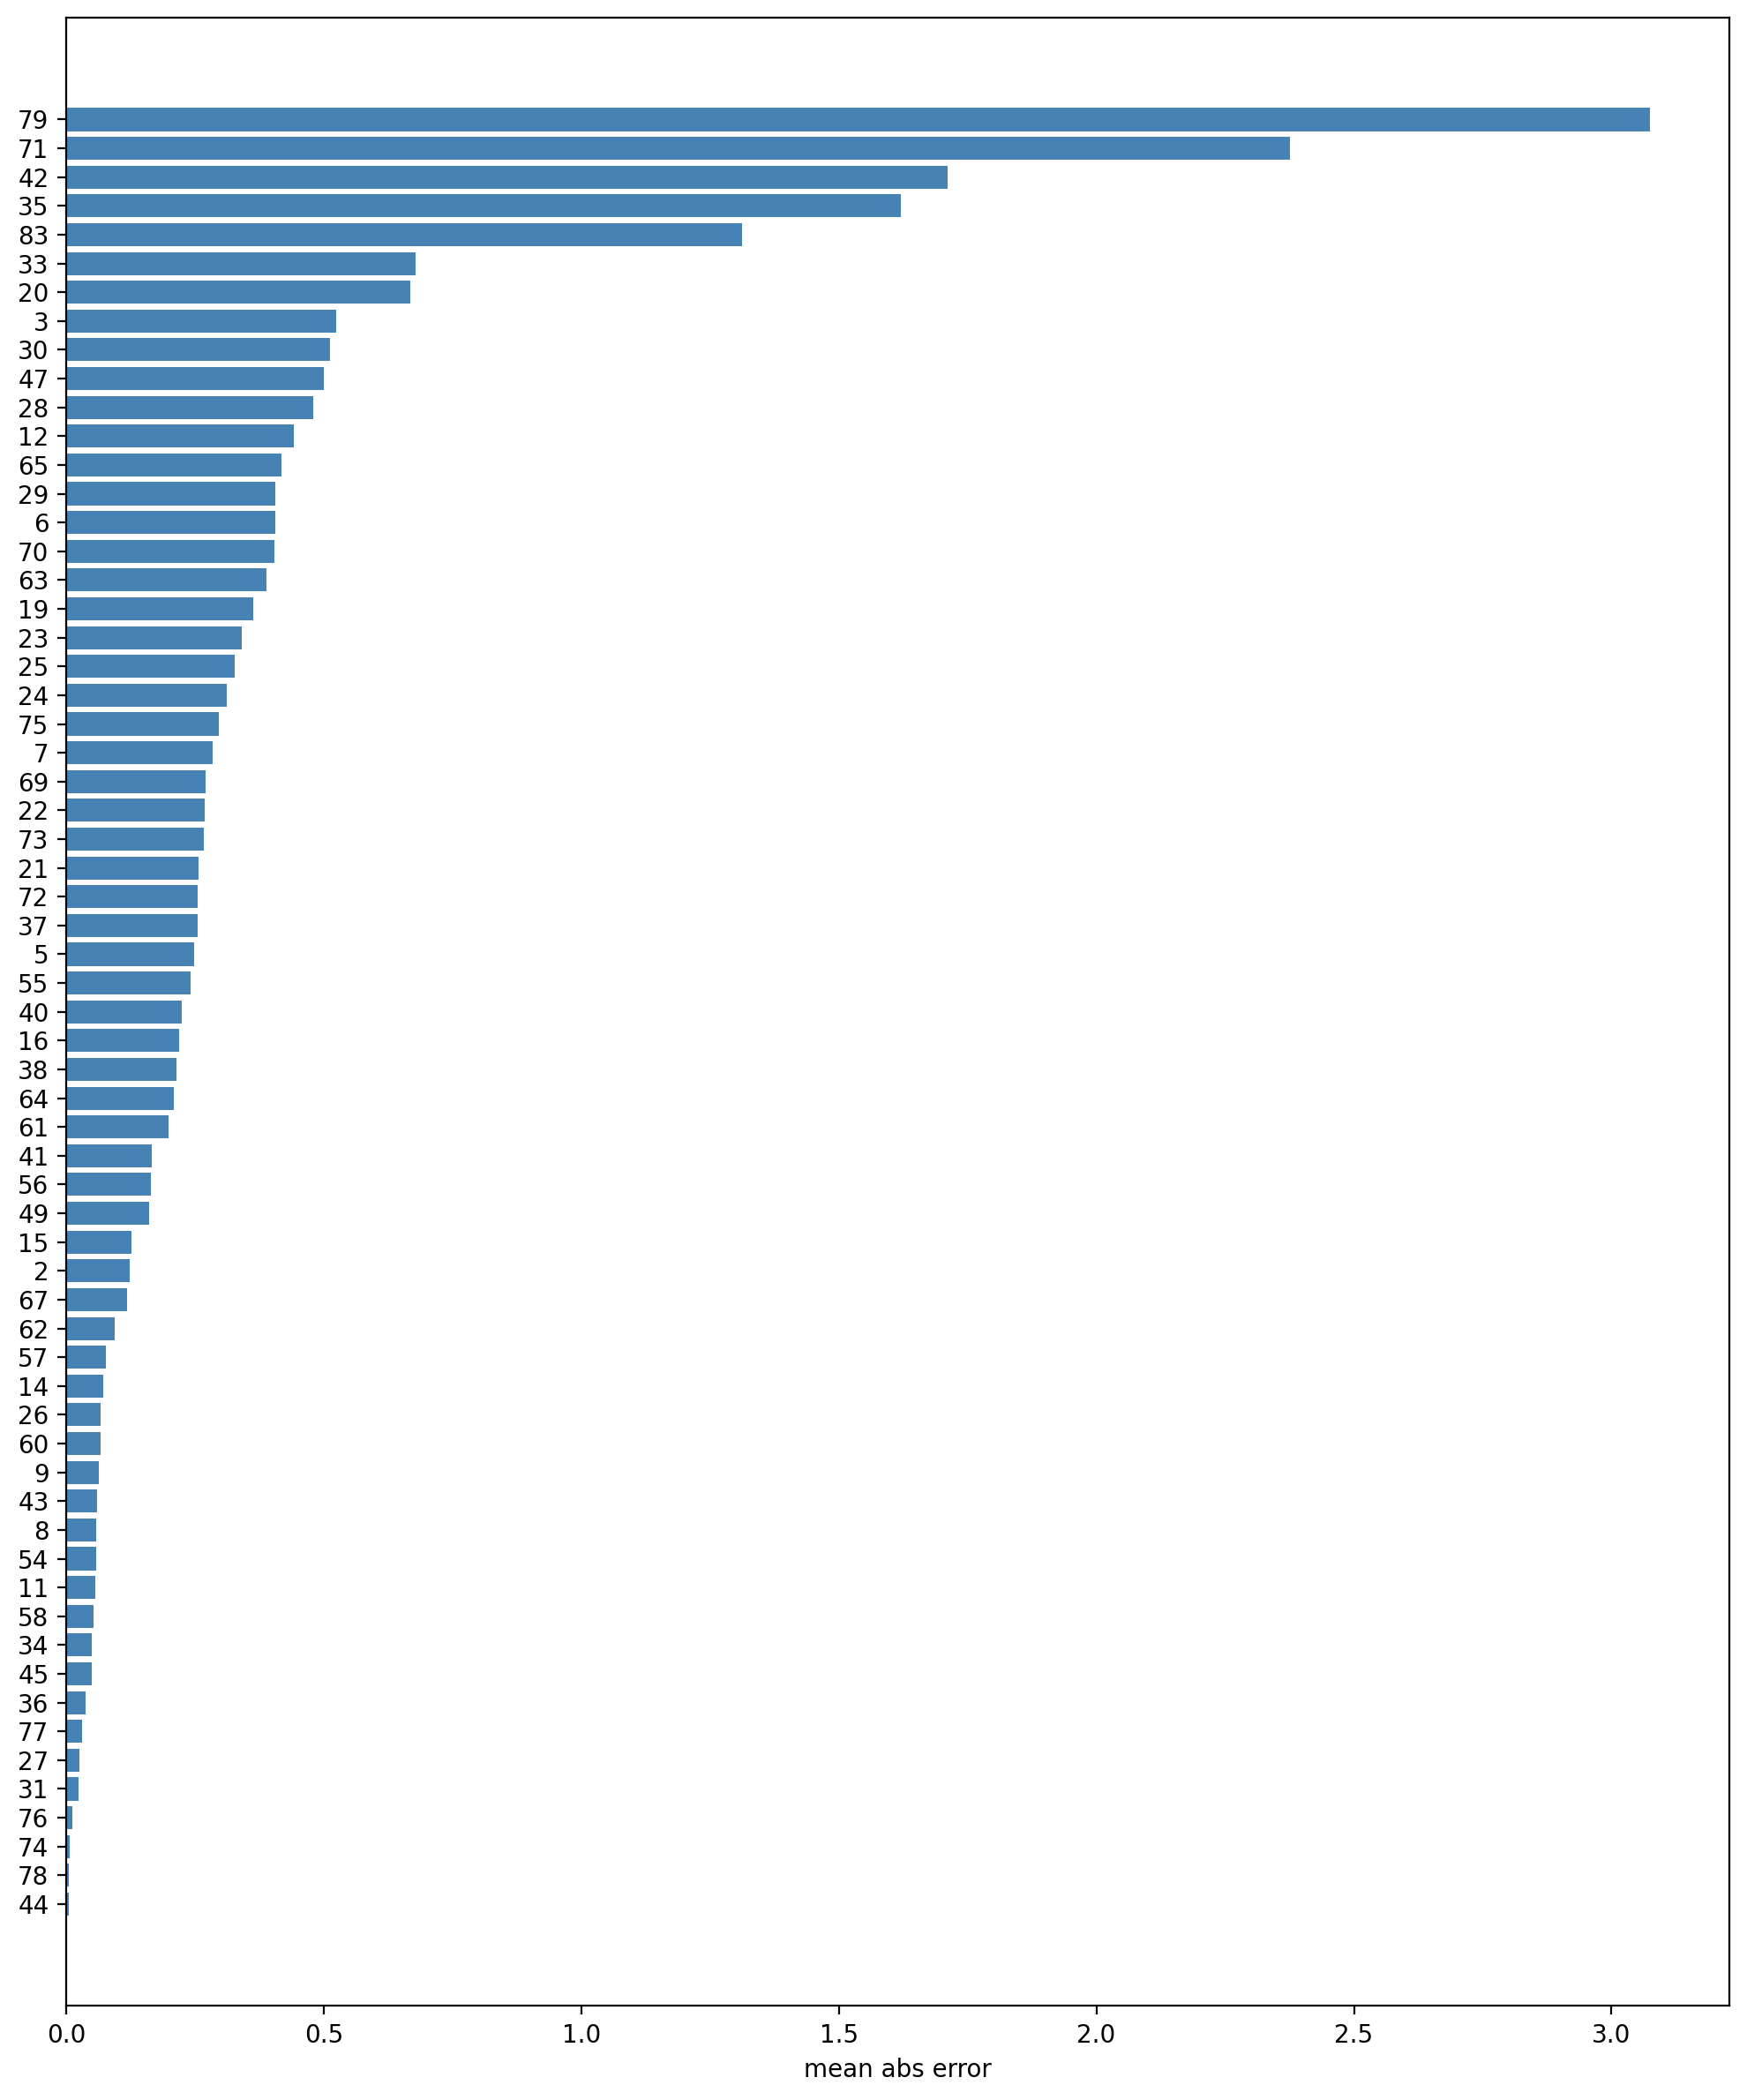

In [43]:
plt.figure(figsize=(10, 12), dpi=200)
plt.barh(item_category_abs.index.astype(str), item_category_abs.values, color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("mean abs error")
plt.tight_layout()

## 71 и 79 выделятся

In [45]:
shop_abs = val_df.groupby("shop_id")["abs_error"].mean().sort_values(ascending=False)

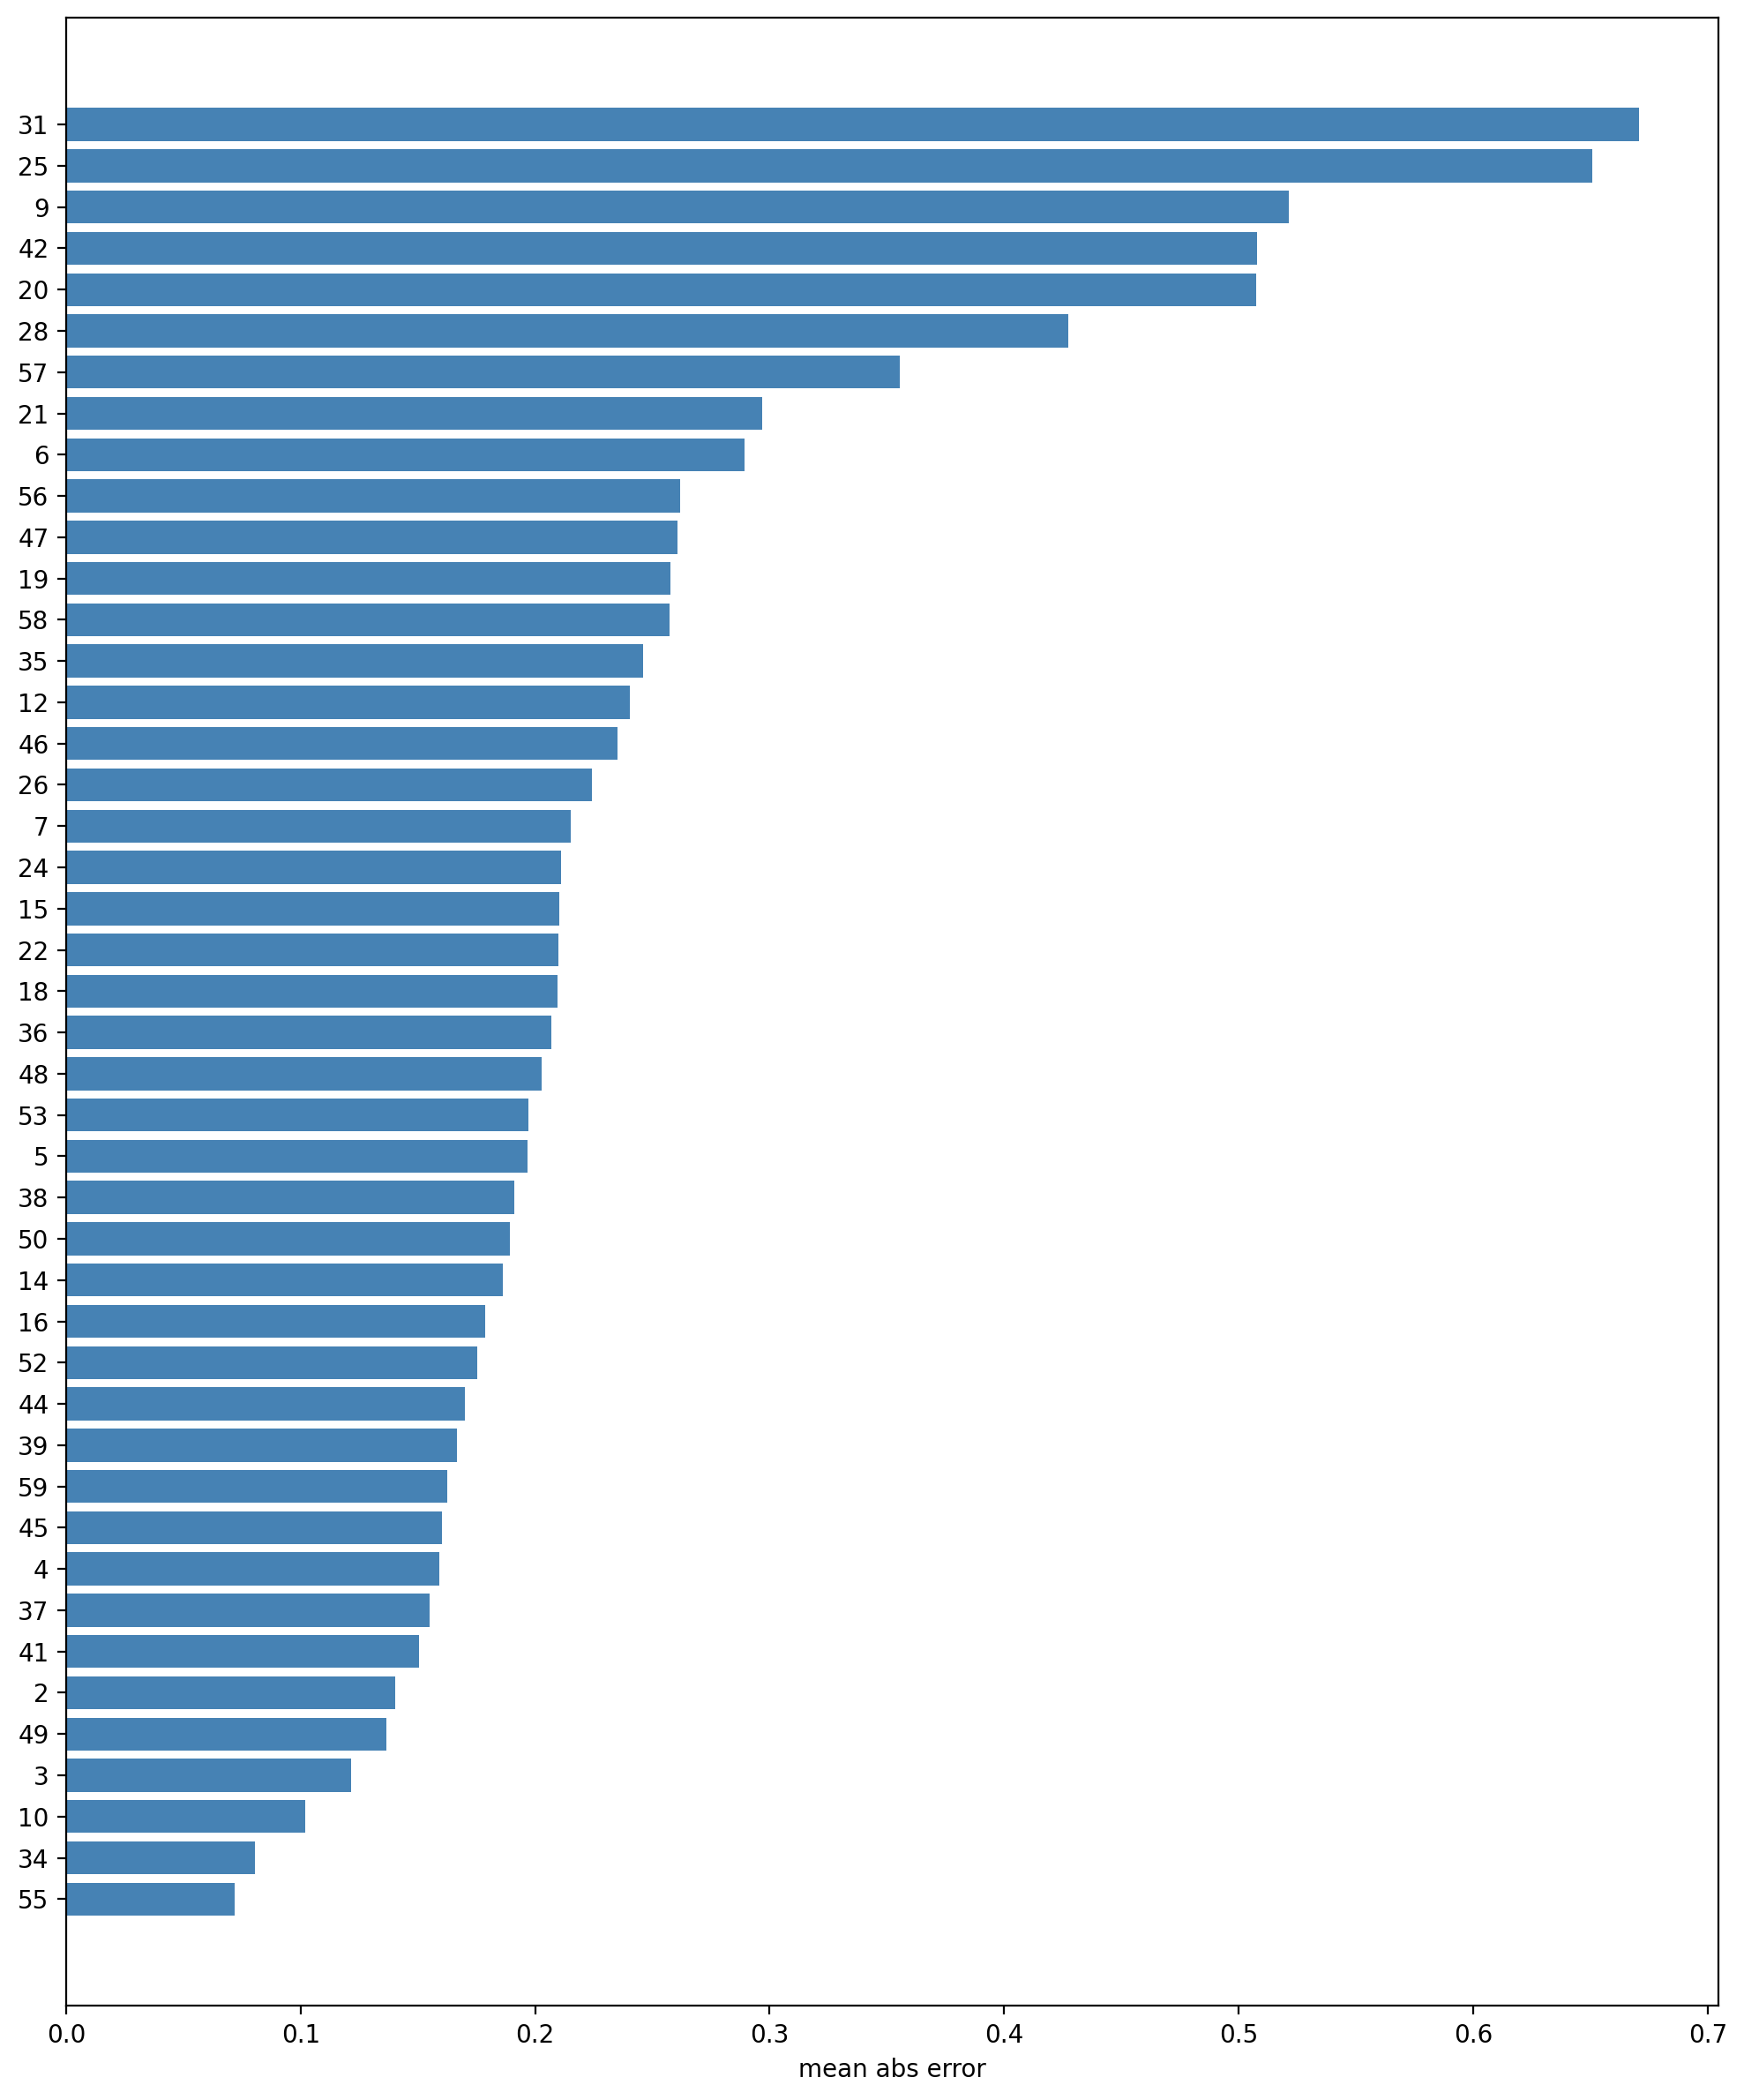

In [47]:
plt.figure(figsize=(10, 12), dpi=200)
plt.barh(shop_abs.index.astype(str), shop_abs.values, color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("mean abs error")
plt.tight_layout()

In [48]:
item_error = val_df.groupby("item_category_id")["error"].mean()

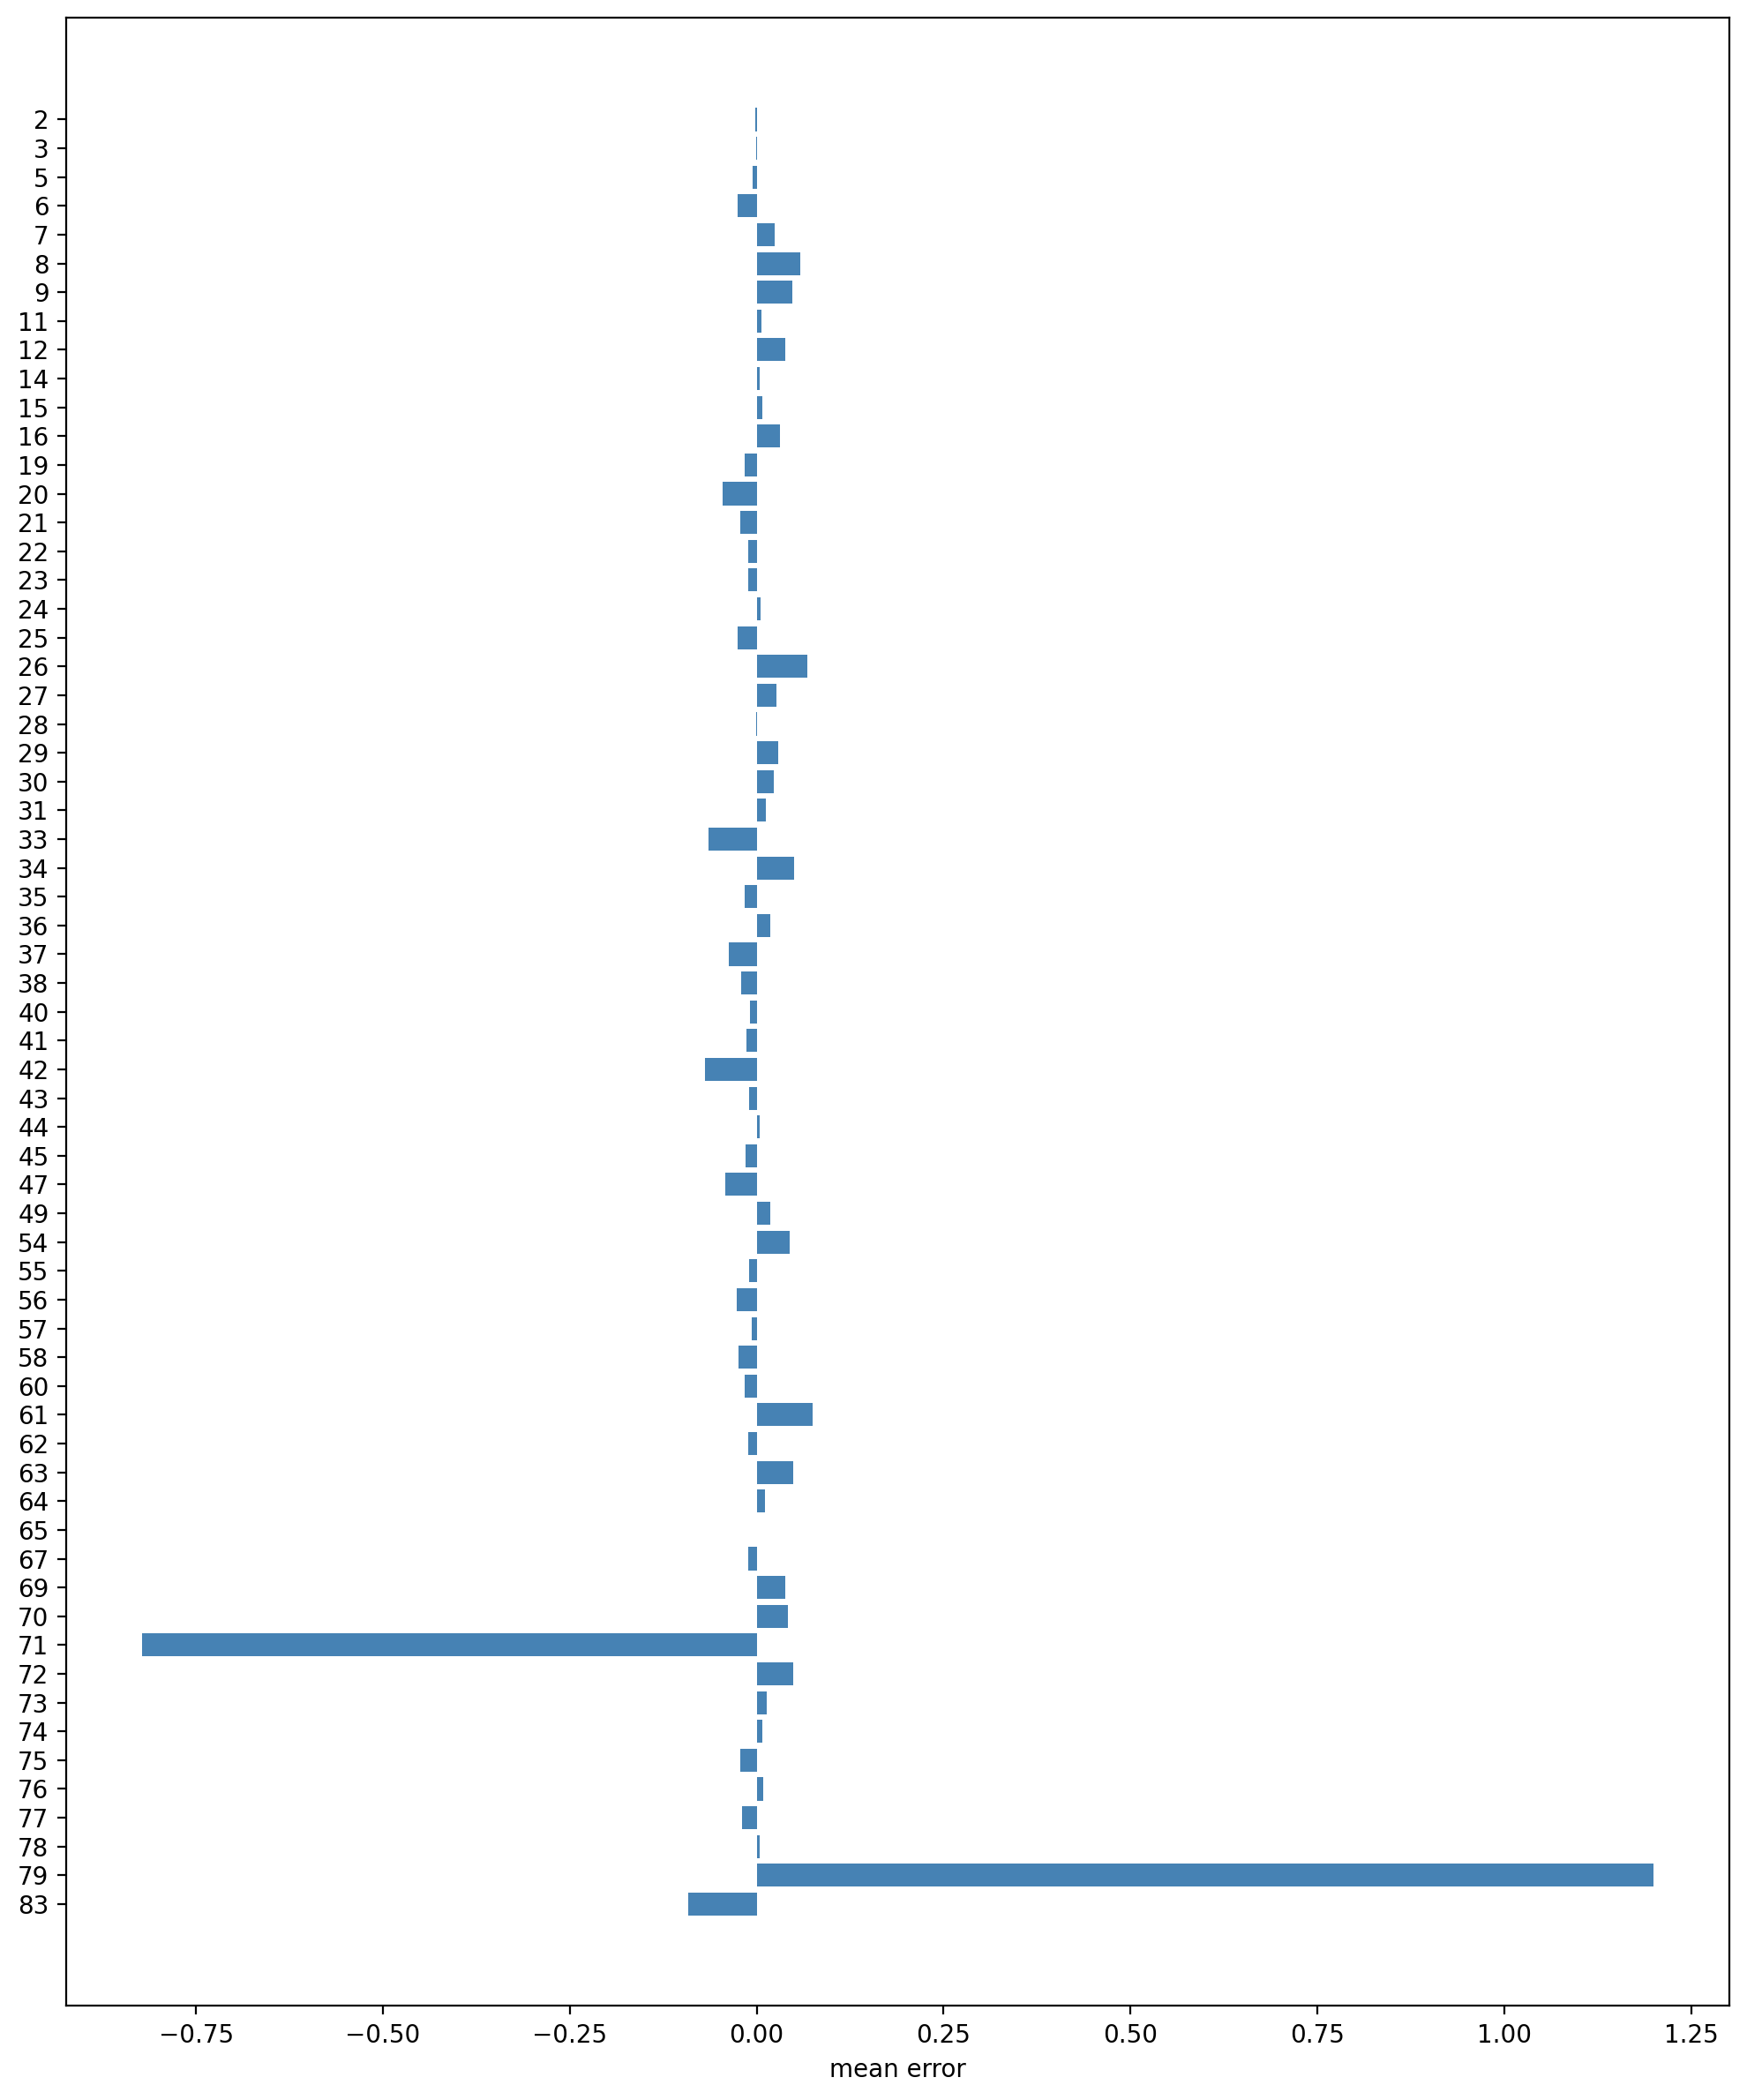

In [53]:
plt.figure(figsize=(10, 12), dpi=200)
plt.barh(item_error.index.astype(str), item_error.values, color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("mean error")
plt.tight_layout()

 ## у 71 занижает сильно , у 79 завышает сильно 

In [55]:
val_df["sales_bucket"] = pd.cut(
    val_df["y_true"],
    bins=[-0.1, 0, 0.5, 2, 5, 20],
    labels=["zero", "low", "mid", "high", "very_high"]
)
order = ["zero", "low", "mid", "high", "very_high"]

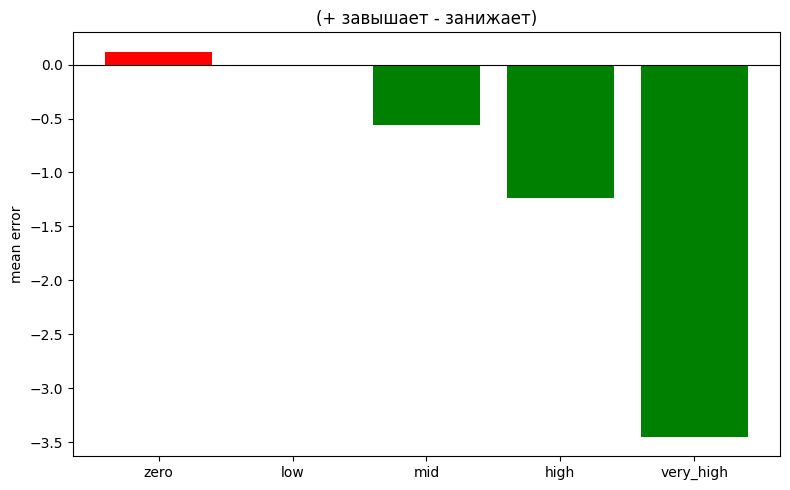

In [57]:
bias = val_df.groupby("sales_bucket")["error"].mean().reindex(order)
colors = ["red" if v > 0 else "green" for v in bias]

plt.figure(figsize=(8, 5))
plt.bar(order, bias.values, color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("(+ завышает - занижает)")
plt.ylabel("mean error")
plt.tight_layout()


## сильно занижает для продаж в среднем в (2, 5 и 20) штук. больше для ~20

In [72]:
pivot = val_df.groupby(["item_category_id", "month"])["abs_error"].mean().unstack()
top_cats = val_df.groupby("item_category_id")["abs_error"].sum().sort_values(ascending=False).index

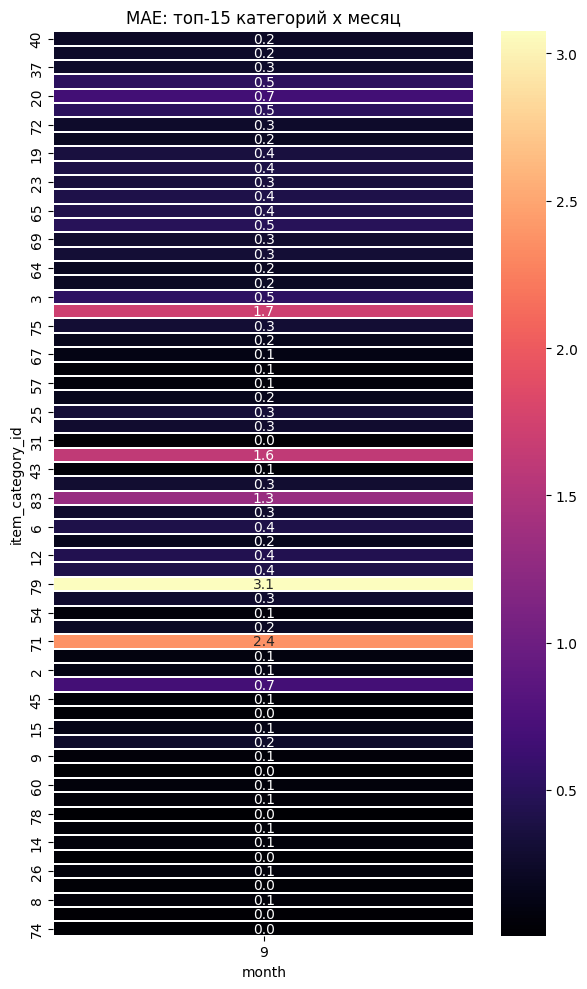

In [74]:
plt.figure(figsize=(6, 10))
sns.heatmap(pivot.loc[top_cats], cmap="magma", linewidths=0.3, annot=True, fmt=".1f")
plt.title("MAE: топ-15 категорий x месяц")
plt.xlabel("month")
plt.ylabel("item_category_id")
plt.tight_layout()

## опять 71 79 категории 

In [111]:
category_71_79_sum = (df[df["item_category_id"].isin([71, 79])]
         .groupby(["date_block_num", "item_category_id"])["item_cnt_month"]
         .sum().reset_index())

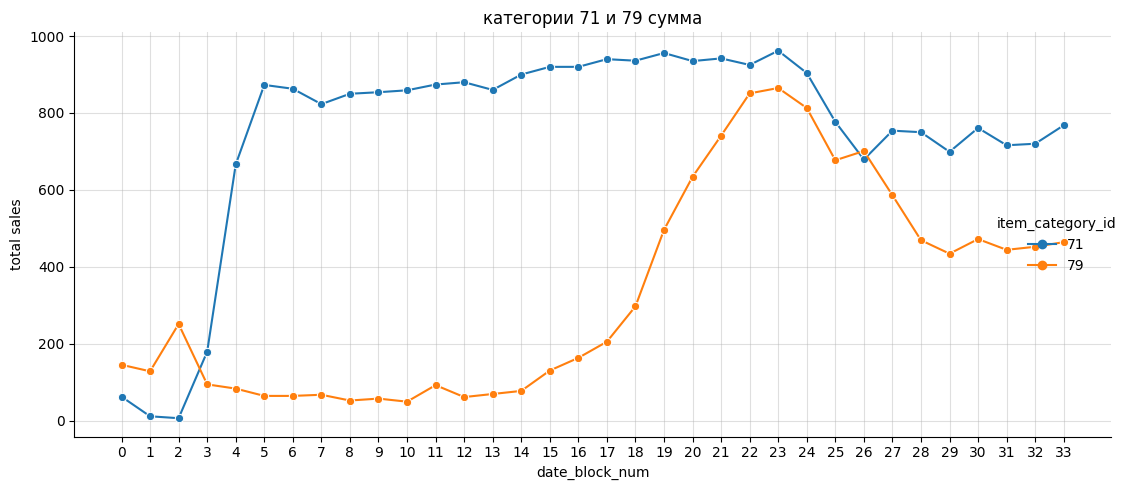

In [116]:
g = sns.relplot(
    data=category_71_79_sum,
    x="date_block_num",
    y="item_cnt_month",
    hue="item_category_id",
    kind="line",
    marker="o",
    aspect=2,

    palette="tab10"
)
g.set(xticks=range(0, 34))
g.ax.grid(True, alpha=0.4)
g.set_axis_labels("date_block_num", "total sales")
plt.title("категории 71 и 79 сумма")
plt.tight_layout()


In [107]:
category_71_79_mean = (df[df["item_category_id"].isin([71, 79])]
         .groupby(["date_block_num", "item_category_id"])["item_cnt_month"]
         .mean().reset_index())

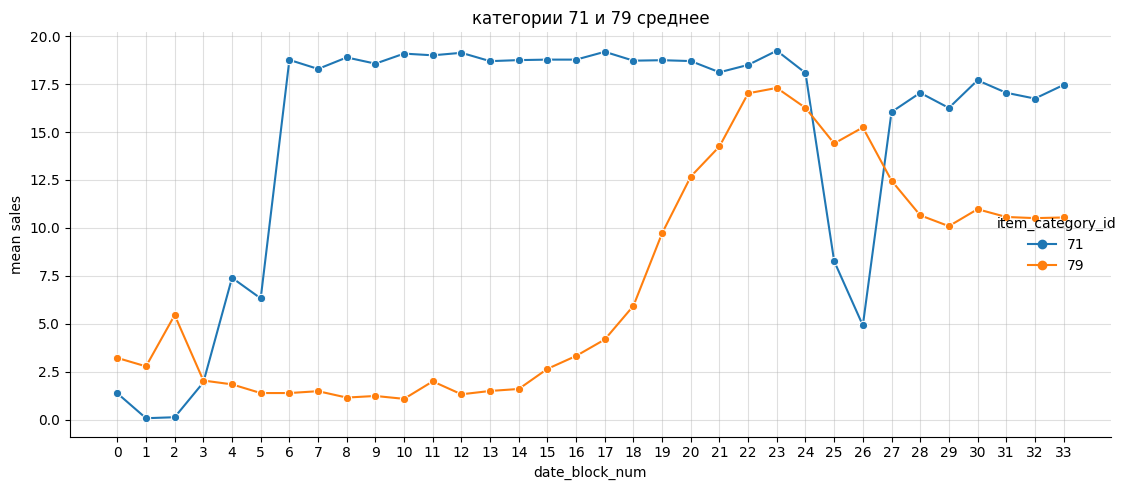

In [119]:
g = sns.relplot(
    data=category_71_79_mean,
    x="date_block_num",
    y="item_cnt_month",
    hue="item_category_id",
    kind="line",
    marker="o",
    aspect=2,
    palette="tab10"
)
g.set(xticks=range(0, 34))
g.ax.grid(True, alpha=0.4)
g.set_axis_labels("date_block_num", "mean sales")
plt.title("категории 71 и 79 среднее")
plt.tight_layout()


## у 71 резкий рост потом стабильно много продаж и резкий обвал, возможно из него модель занижает его.
## у 79 долго был внизу, потом стал расти и получается модель большую часть училась на том, что он растет , отсюда и завышение на 1.2

---

In [198]:
model_cat.get_feature_importance(prettified=True)

,Feature Id,Importances
0,item_avg_cnt,47.022339
1,shop_avg_cnt,14.161062
2,item_cnt_month_lag_1,9.512333
3,shop_id,6.961157
4,item_cnt_month_rmean_3,5.275777
5,item_avg_cnt_lag_1,3.841355
6,item_category_id,3.149063
7,avg_price_lag_1,1.313724
8,item_avg_cnt_lag_2,1.035304
9,item_cnt_month_lag_2,0.941213


In [199]:
pred_cat = model_cat.predict(X_test_cat).clip(0, 20)
pd.DataFrame({"ID": test["ID"], "item_cnt_month": pred_cat}).to_csv("../data/submission/cat7_submission.csv", index=False)

## Private Score 1.02762 ;(

---